# ARTI 403 Image Processing
## Lab 4: Intensity Transformations and Filtering

Name: Mohammed Saeed Alamodi
ID: 2240009007

The parrot image from the manual wasnt included with the lab so I used the coffee image from skimage for the thresholding part. I also used matplotlib to show the images since cv2.imshow doesnt work in jupyter.

## Task 1: Thresholding

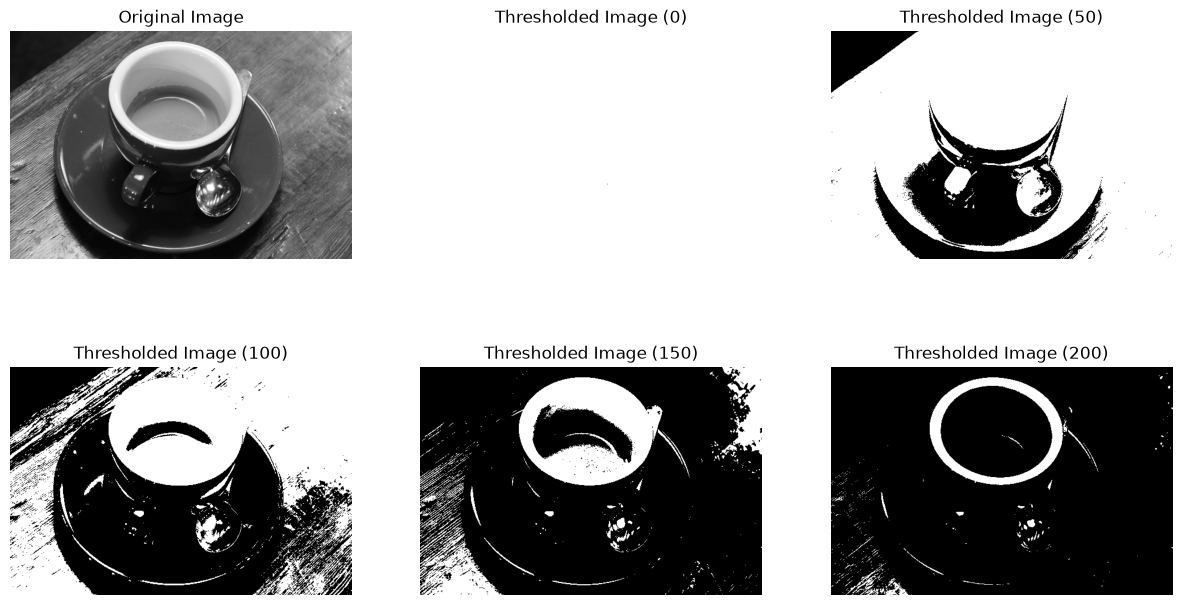

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('images/coffee.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i + 2)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Thresholded Image ({threshold_value})')
    plt.axis('off')

plt.show()

When the threshold is 0 the whole image becomes white. The higher the threshold the more black pixels we get, at 200 only the rim of the cup and some spots on the spoon stay white. I think 150 gives the best result here because the cup is separated from the saucer.

## Task 2: Histogram Processing
Step 1: Load necessary libraries

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

Step 2: Load moon image

In [3]:
img = data.moon()

Step 3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

In [4]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

Step 4: Display the image with its histogram of step 2 and step 3

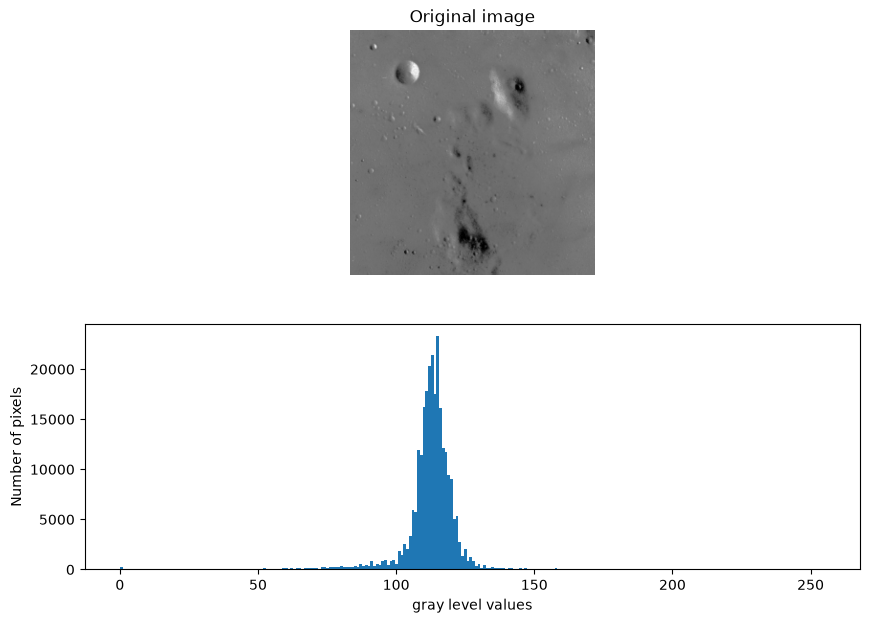

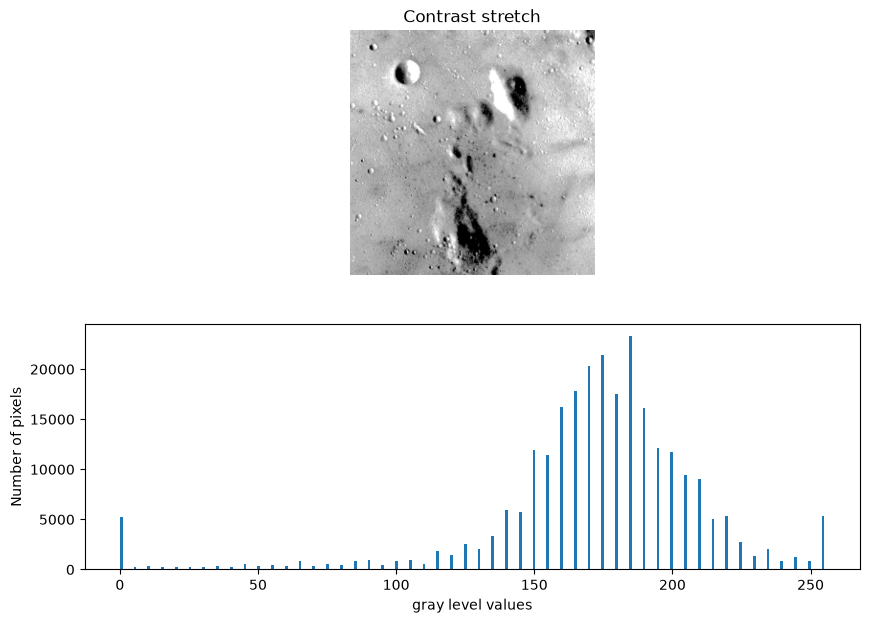

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Assessment

## Task 1
Rescale the moon image using the 3rd and 80th percentiles and plot the histogram

87.0 118.0


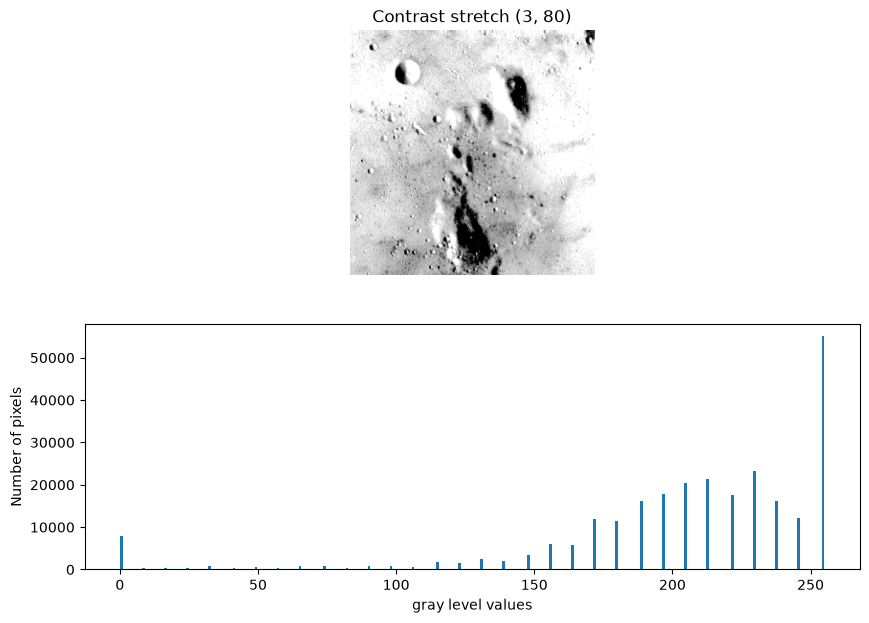

In [6]:
p3, p80 = np.percentile(img, (3, 80))
print(p3, p80)
img_rescale2 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale2, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3, 80)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale2.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

The image became much brighter than the 2 to 98 one. All the pixels above 118 (the 80th percentile) became 255 so theres a big spike at the end of the histogram and the bright parts look washed out. The histogram also has gaps between the bars because the moon only has a small range of gray levels that got stretched to 0 to 255.

## Task 2
Histogram equalization on the moon image using exposure.equalize_hist

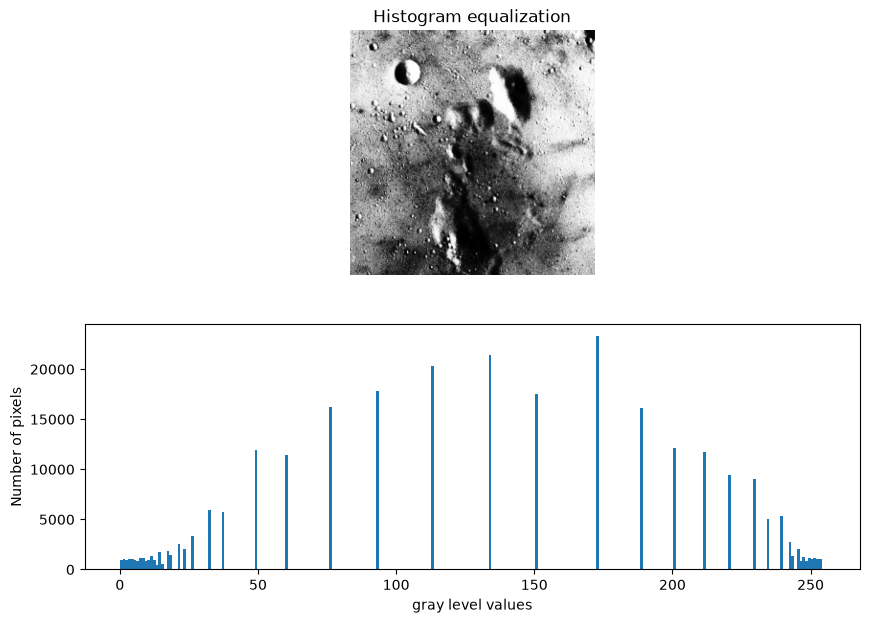

In [7]:
img_eq = exposure.equalize_hist(img)
img_eq = (img_eq * 255).astype(np.uint8)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

I multiplied by 255 because equalize_hist gives values between 0 and 1. After equalization the pixels are spread over the whole range so the histogram is flatter than the original and the image has more contrast, the craters are much clearer. The noise in the dark areas became more visible too.

## Task 3
Histogram matching with the rocket image as reference and the chelsea image as the source

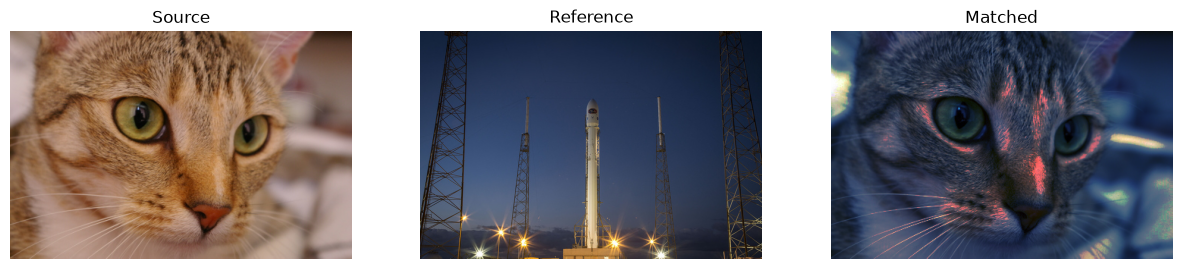

In [8]:
reference = data.rocket()
image = data.chelsea()

matched = exposure.match_histograms(image, reference, channel_axis=-1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title('Source')
ax[1].imshow(reference)
ax[1].set_title('Reference')
ax[2].imshow(matched.astype(np.uint8))
ax[2].set_title('Matched')
for a in ax:
    a.axis('off')
plt.show()

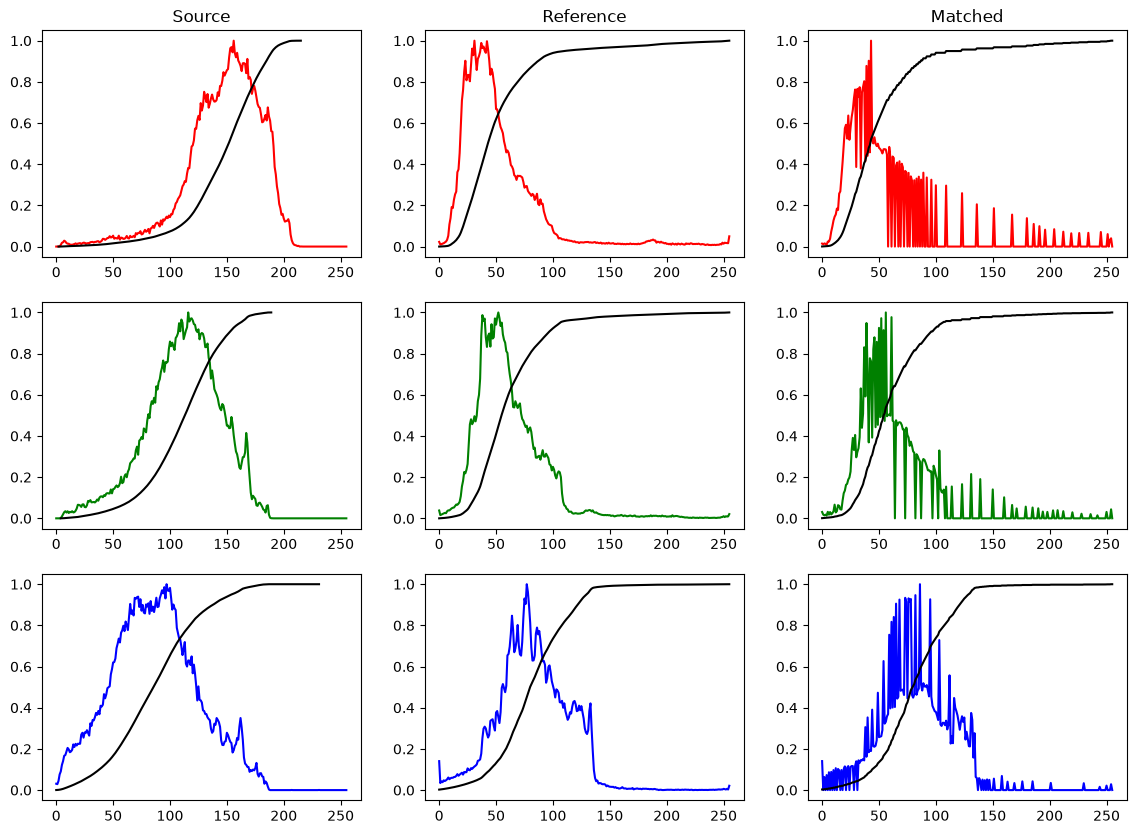

In [9]:
fig, ax = plt.subplots(3, 3, figsize=(14, 10))

for i, im in enumerate((image, reference, matched)):
    for c, col in enumerate(('red', 'green', 'blue')):
        hist, bins = exposure.histogram(im[..., c], source_range='dtype')
        ax[c, i].plot(bins, hist / hist.max(), color=col)
        cdf, bins = exposure.cumulative_distribution(im[..., c])
        ax[c, i].plot(bins, cdf, color='black')

ax[0, 0].set_title('Source')
ax[0, 1].set_title('Reference')
ax[0, 2].set_title('Matched')
plt.show()

The cat image now has colors close to the rocket image, its darker and mostly blue like the sky in the rocket picture. The black lines (cdf) of the matched image are almost the same as the reference in all 3 channels so the matching worked.